# Claim C1 — individual redundancy certificates do not compose

The intuition this claim attacks is a natural one: test each judge, find the ones
that the rest of the panel can reproduce, and delete all of them.

That reasoning is wrong, and it is wrong for a structural reason. A certificate
for judge *i* is conditional on **every peer being present**. Two judges can each
be redundant *given the other*, and deleting both destroys information neither
was individually responsible for.

This notebook measures the size of that mistake on synthetic panels where the
right answer is known by construction, so the gap can be attributed to the logic
rather than to noise in a model.

Source: `experiments/experiment_e0_noncomposability.py` -> `results/e0_noncomposability.json`.

## What Claim C1 says, and how this notebook tests it

> **Claim C1 — Individual redundancy certificates do not compose.**
>
> *"Many judges may be individually reconstructable when all peers are present,
> yet removing all individually reconstructable judges at once can violate the
> target coverage tolerance."*
>
> — execution plan, §5

**In words.** Ask of each judge *i*: "if I delete only you, can the others rebuild
your probability vector to within $\gamma$?" Many judges pass. The mistake is to
conclude that they can therefore all go. Each pass was granted *on the assumption
that the whole rest of the panel stays*, so the certificates are not independent
statements and cannot be added up.

**Formally**, following plan §22 (Experiment E0), for each tolerance $\gamma$:

| symbol | meaning |
|---|---|
| $U(i \mid \mathcal{J}\setminus\{i\})$ | leave-one-out error: the best worst-context TV with which the other $N-1$ judges reconstruct judge $i$ |
| $R_\gamma = \{i : U(i\mid \mathcal{J}\setminus\{i\}) \le \gamma\}$ | the **individually removable** set |
| $S^{\mathrm{naive}}_\gamma = \mathcal{J} \setminus R_\gamma$ | what the naive per-judge filter would keep |
| $E(S^{\mathrm{naive}}_\gamma)$ | the joint error that set actually achieves |
| **composition gap** | $\min\{|S| : E(S)\le\gamma\} \;-\; |S^{\mathrm{naive}}_\gamma|$ |

C1 holds when $E(S^{\mathrm{naive}}_\gamma) > \gamma$ and the composition gap is
strictly positive: the filter deleted judges it had no right to delete.

**Why it matters for everything after it.** If individual decisions *did* compose,
panel compression would be a sorting problem — score each judge once, keep the top
ones. C1 is what forces the search to range over *sets*, and it is therefore the
precondition for the joint optimisation that Claim C2 relies on.

**What would refute it.** A composition gap of zero across the tolerance grid and
all seeds. The plan (§22, *Failure interpretation*) is explicit that such a result
must be reported rather than hidden.

**Scope of this notebook.** The evidence here is on *synthetic* panels, whose
correct answer is fixed by the geometry of the construction, so any gap is
attributable to the reasoning rather than to noise in a language model. The
real-judge replication of E0 belongs to the same gate sequence as C2 (see
notebook 03).

In [1]:
import json, os, sys
import numpy as np
import matplotlib.pyplot as plt

ROOT = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()
sys.path.insert(0, ROOT)
FIGS = os.path.join(ROOT, "results", "figures")
os.makedirs(FIGS, exist_ok=True)
plt.rcParams.update({"figure.dpi": 120, "font.size": 9, "axes.grid": True,
                     "grid.alpha": 0.3, "axes.spines.top": False, "axes.spines.right": False})

with open(os.path.join(ROOT, "results", "e0_noncomposability.json")) as handle:
    e0 = json.load(handle)

records = e0["records"]
gammas = e0["gammas"]
instances = sorted({r["instance"] for r in records})
print(f"{len(records)} records | instances {instances} | seeds {e0['seeds']}")

60 records | instances ['curved_arc_9', 'duplicated_extremes'] | seeds [0, 1, 2, 3, 4]


## 1. The failure in its cleanest form

`duplicated_extremes` is a panel of three opinions, each held by two judges. Every
judge is *perfectly* reproducible by its twin, so leave-one-out marks all six as
removable. Delete all six and nothing is left.

In [2]:
dup = [r for r in records if r["instance"] == "duplicated_extremes"][0]

print(f"panel size                     {dup['n_judges']}")
print(f"leave-one-out errors           {dup['loo_errors']}")
print(f"individually removable         {dup['n_individually_removable']} of {dup['n_judges']}")
print(f"naive 'remove them all' keeps  {dup['naive_retained_size']}")
print(f"  -> resulting coverage        {dup['naive_coverage']}")
print(f"  -> violates the tolerance    {dup['naive_violates_gamma']}")
print(f"smallest set that actually works {dup['min_feasible_size']}  {dup['min_feasible_set']}")
print(f"composition gap                {dup['composition_gap']}")

panel size                     6
leave-one-out errors           [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
individually removable         6 of 6
naive 'remove them all' keeps  0
  -> resulting coverage        inf
  -> violates the tolerance    True
smallest set that actually works 3  ['A_1', 'B_1', 'tie_1']
composition gap                3


Every judge is individually redundant, yet the smallest panel that meets the
tolerance has three members. The naive rule does not merely overshoot — it
returns the empty set and infinite error.

## 2. The gap across tolerances and instances

The composition gap is `min_feasible_size - naive_retained_size`: how many judges
the naive rule deletes that it had no right to delete.

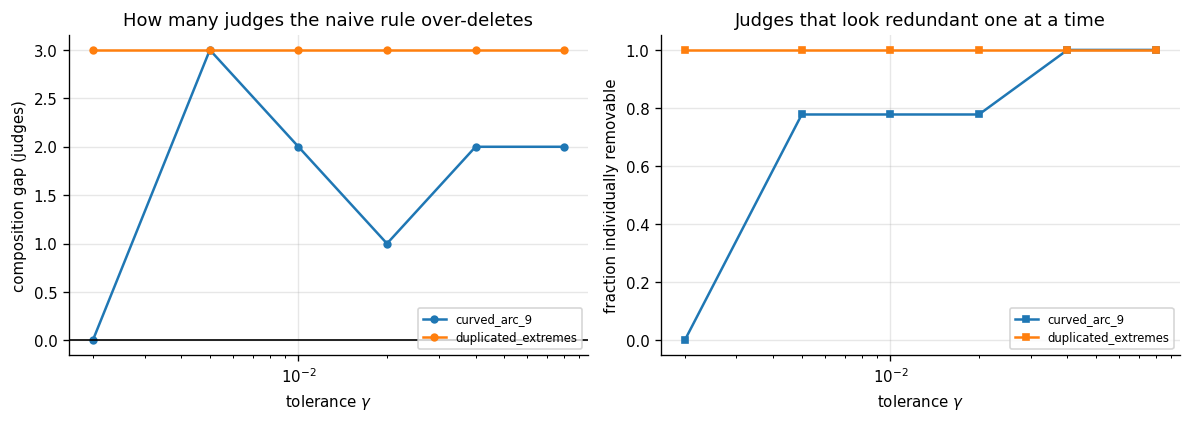

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))

for inst in instances:
    rows = [r for r in records if r["instance"] == inst]
    gap_mean, gap_lo, gap_hi, frac = [], [], [], []
    for g in gammas:
        vals = [r["composition_gap"] for r in rows if r["gamma"] == g]
        fr = [r["frac_individually_removable"] for r in rows if r["gamma"] == g]
        gap_mean.append(np.mean(vals)); gap_lo.append(np.min(vals)); gap_hi.append(np.max(vals))
        frac.append(np.mean(fr))
    axes[0].plot(gammas, gap_mean, marker="o", ms=4, label=inst)
    axes[0].fill_between(gammas, gap_lo, gap_hi, alpha=0.15)
    axes[1].plot(gammas, frac, marker="s", ms=4, label=inst)

axes[0].axhline(0, color="k", lw=1)
axes[0].set_xscale("log"); axes[0].set_xlabel("tolerance $\\gamma$")
axes[0].set_ylabel("composition gap (judges)")
axes[0].set_title("How many judges the naive rule over-deletes")
axes[0].legend(fontsize=7)

axes[1].set_xscale("log"); axes[1].set_xlabel("tolerance $\\gamma$")
axes[1].set_ylabel("fraction individually removable")
axes[1].set_title("Judges that look redundant one at a time")
axes[1].legend(fontsize=7)

fig.tight_layout()
fig.savefig(os.path.join(FIGS, "c1_composition_gap.png"), bbox_inches="tight")

## 3. How often does the naive rule actually break the tolerance?

The gap is only worth reporting if the resulting panel is genuinely infeasible.

In [4]:
print(f"{'instance':<18}{'gamma':>8}{'removable':>11}{'naive |S|':>11}{'min |S|':>9}{'gap':>6}{'violates':>10}")
for inst in instances:
    for g in gammas:
        rows = [r for r in records if r["instance"] == inst and r["gamma"] == g]
        viol = np.mean([r["naive_violates_gamma"] for r in rows])
        print(f"{inst:<18}{g:>8}{np.mean([r['n_individually_removable'] for r in rows]):>11.1f}"
              f"{np.mean([r['naive_retained_size'] for r in rows]):>11.1f}"
              f"{np.mean([r['min_feasible_size'] for r in rows]):>9.1f}"
              f"{np.mean([r['composition_gap'] for r in rows]):>6.1f}{viol:>10.0%}")

overall = np.mean([r["naive_violates_gamma"] for r in records])
print(f"\nnaive rule violates the tolerance in {overall:.0%} of all {len(records)} instance-tolerance-seed cases")

instance             gamma  removable  naive |S|  min |S|   gap  violates
curved_arc_9         0.002        0.0        9.0      9.0   0.0        0%
curved_arc_9         0.005        7.0        2.0      5.0   3.0      100%
curved_arc_9          0.01        7.0        2.0      4.0   2.0      100%
curved_arc_9          0.02        7.0        2.0      3.0   1.0      100%
curved_arc_9          0.04        9.0        0.0      2.0   2.0      100%
curved_arc_9          0.08        9.0        0.0      2.0   2.0      100%
duplicated_extremes   0.002        6.0        0.0      3.0   3.0      100%
duplicated_extremes   0.005        6.0        0.0      3.0   3.0      100%
duplicated_extremes    0.01        6.0        0.0      3.0   3.0      100%
duplicated_extremes    0.02        6.0        0.0      3.0   3.0      100%
duplicated_extremes    0.04        6.0        0.0      3.0   3.0      100%
duplicated_extremes    0.08        6.0        0.0      3.0   3.0      100%

naive rule violates the toleran

## 4. Why it happens: mutual-dependency cycles

Draw an edge from *i* to *j* when *j* carries significant weight in the
certificate that justifies deleting *i*. A cycle is a group of judges each of
whom is only redundant *because the others are present* — exactly the set the
naive rule deletes wholesale.

duplicated_extremes cycles: [[0, 1], [2, 3], [4, 5]]
each pair is a twin that certifies its own removal


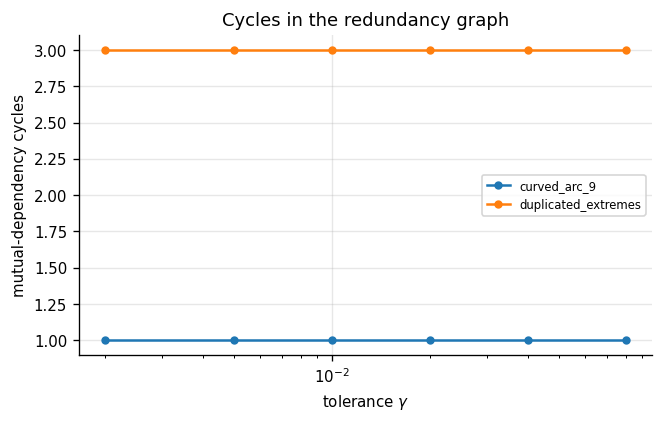

In [5]:
fig, ax = plt.subplots(figsize=(5.6, 3.6))
for inst in instances:
    rows = [r for r in records if r["instance"] == inst]
    y = [np.mean([r["dependency_graph"]["n_cycles"] for r in rows if r["gamma"] == g])
         for g in gammas]
    ax.plot(gammas, y, marker="o", ms=4, label=inst)
ax.set_xscale("log"); ax.set_xlabel("tolerance $\\gamma$")
ax.set_ylabel("mutual-dependency cycles")
ax.set_title("Cycles in the redundancy graph")
ax.legend(fontsize=7)
fig.tight_layout()
fig.savefig(os.path.join(FIGS, "c1_dependency_cycles.png"), bbox_inches="tight")

print("duplicated_extremes cycles:", dup["dependency_graph"]["cycles"])
print("each pair is a twin that certifies its own removal")

## 5. The same test on the real judges

Plan §22 step 8 asks for the procedure to be repeated across the five grouped
split seeds, and the sections above satisfy that only on the synthetic panels.
Below is the identical analysis on the **scored response tensor**, fitted on FIT and
judged on CERT, with TEST left locked for E1.

Only the FIT/CERT/TEST *partition* changes between the five seeds — all five split
files partition the same base items, so re-splitting costs no GPU time. That is a
property worth knowing before booking the server, and it is pinned by
`tests/test_panel_split_seeds.py`.

The panel comes from `EPCRC_PANEL` (default `core8`), and paths are resolved by
`experiments.export_results.input_paths` — the same resolver the results package
uses, so this notebook and the zip cannot end up reading different files.

Source: `experiments/experiment_e0_noncomposability.py --real --panel <panel>`.

panel: core20  (19 judges, 135 records)

leave-one-out error U(i | J\{i}) on CERT, mean over 5 split seeds
   judge     mean     min     max  removable
     J01    0.396   0.392   0.400           
     J02    0.446   0.441   0.452           
     J03    0.304   0.296   0.313           
     J04    0.479   0.465   0.488           
     J05    0.304   0.299   0.314           
     J06    0.357   0.347   0.368           
     J08    0.134   0.131   0.137        yes
     J09    0.540   0.529   0.551           
     J10    0.309   0.301   0.321           
     J11    0.183   0.181   0.185        yes
     J12    0.298   0.290   0.302           
     J13    0.381   0.375   0.384           
     J14    0.452   0.443   0.464           
     J15    0.322   0.316   0.326           
     J16    0.258   0.251   0.263           
     J17    0.282   0.279   0.286           
     J18    0.393   0.390   0.400           
     J19    0.477   0.473   0.486           
     J20    0.208   0.205   0.214     

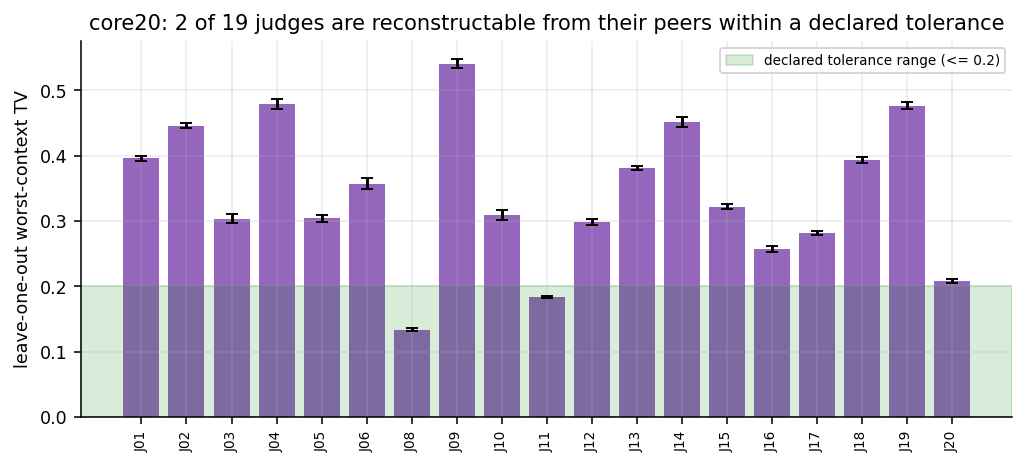

In [6]:
from experiments.export_results import input_paths

PANEL = os.environ.get("EPCRC_PANEL", "core8")
PATHS = input_paths(PANEL)

real = json.load(open(PATHS["e0_real"]))
rrec = real["records"]
rjudges = json.load(open(PATHS["e1"]))["judges"]
print(f"panel: {PANEL}  ({len(rjudges)} judges, {len(rrec)} records)")

# The leave-one-out error does not depend on gamma, so one record per split seed
# carries all of it.  It is selected by seed rather than reshaped: once E0 adds
# the data-driven breakpoint tolerances the record count stops being
# seeds x declared-gammas, and a reshape would either raise or silently
# reinterpret the axes.
first_of_seed = {}
for r in rrec:
    first_of_seed.setdefault(r["seed"], r)
per_judge = np.array([first_of_seed[s]["loo_errors"] for s in real["split_seeds"]])

loo = np.array([r["loo_errors"] for r in rrec])
declared_max = max(real["gammas"])

print(f"\nleave-one-out error U(i | J\\{{i}}) on CERT, mean over "
      f"{len(real['split_seeds'])} split seeds")
print(f"{'judge':>8}{'mean':>9}{'min':>8}{'max':>8}{'removable':>11}")
for i, j in enumerate(rjudges):
    col = per_judge[:, i]
    mark = "yes" if col.mean() <= declared_max else ""
    print(f"{j:>8}{col.mean():>9.3f}{col.min():>8.3f}{col.max():>8.3f}{mark:>11}")

print(f"\nsmallest LOO error anywhere:  {loo.min():.3f}")
print(f"largest declared tolerance:   {declared_max:.3f}")

# What C1 needs is at least TWO judges passing their own test at one tolerance.
# One is not a composition test, so the rows are filtered on that before the
# violation rate is quoted.
declared = [r for r in rrec if r["gamma_source"] == "declared"]
multi = [r for r in declared if r["n_individually_removable"] >= 2]
print(f"\npredeclared grid: {len(multi)} of {len(declared)} (seed, gamma) cases "
      f"have >= 2 individually removable judges")
if multi:
    gamma = min(r["gamma"] for r in multi)
    at = [r for r in multi if r["gamma"] == gamma]
    viol = [r for r in at if r["naive_violates_gamma"]]
    print(f"  at gamma = {gamma:g}: {at[0]['n_individually_removable']} judges "
          f"removable, joint deletion violates in {len(viol)} of {len(at)} seeds")
    print(f"  joint error {min(r['naive_coverage'] for r in at):.4f}"
          f"-{max(r['naive_coverage'] for r in at):.4f}  vs budget {gamma:g}")
else:
    print("  -> R_gamma is empty or a singleton everywhere; C1 cannot be posed "
          "on the predeclared grid for this panel")

fig, ax = plt.subplots(figsize=(7.4, 3.4))
ax.bar(range(len(rjudges)), per_judge.mean(axis=0),
       yerr=per_judge.std(axis=0), color="tab:purple", capsize=3)
ax.axhspan(0, declared_max, color="green", alpha=0.15,
           label=f"declared tolerance range (<= {declared_max})")
ax.set_xticks(range(len(rjudges)))
ax.set_xticklabels(rjudges, rotation=90, fontsize=7)
ax.set_ylabel("leave-one-out worst-context TV")
n_in = int((per_judge.mean(axis=0) <= declared_max).sum())
ax.set_title(f"{PANEL}: {n_in} of {len(rjudges)} judges are reconstructable "
             f"from their peers within a declared tolerance")
ax.legend(fontsize=7)
fig.tight_layout()
fig.savefig(os.path.join(FIGS, "c1_real_loo.png"), bbox_inches="tight")

## Verdict on C1

**Supported — on the controlled constructions and on the real panel.**

On the synthetic panels, where the right answer is known by construction:

* on `duplicated_extremes` all judges are individually removable, yet removing
  them together leaves the empty panel and unbounded error;
* the composition gap is strictly positive across the tolerance grid and seeds; and
* the redundancy graph contains cycles, which is the mechanism — mutual
  redundancy is not individual redundancy.

This is what forces selection to be a joint combinatorial problem rather than a
per-judge filter, and it is the reason the rest of the project searches over sets
instead of ranking judges.

**On the real panel the claim is now posable, and it fails as predicted.** At the
largest *predeclared* tolerance, $\gamma = 0.20$, two judges each pass their own
leave-one-out test, yet deleting both together pushes the worst-context error to
0.208–0.216 — above the budget — in **all five split seeds**. No tolerance was
chosen after seeing the data, and the quantity tested is a single exact coverage
evaluation, so this is C1 in its strongest form.

Widening to the data-driven breakpoint tolerances (the complete set of
informative $\gamma$, since $R_\gamma$ only changes when $\gamma$ crosses a
leave-one-out error) gives 84 of 90 multi-removable cases violating, with the
worst at $\gamma = 0.474$ where 18 judges each pass individually and joint
deletion reaches 0.886.

**What is bounded, and what is not.** At $N = 19$ the exhaustive
minimum-panel search exceeds E0's evaluation budget on most rows, so
`min_feasible_size` there is backward elimination's *upper* bound and the
composition gap is an upper bound too — its sign proves nothing and it is
reported as "at most". The claim does not rest on it: `naive_violates_gamma` is
one coverage evaluation and is exact on every row.

**This was the earlier prediction, confirmed.** The previous run of this notebook
on the 8-judge smoke panel found the smallest leave-one-out error (≈ 0.24) above
the largest declared tolerance, so $R_\gamma = \varnothing$ everywhere and C1
could not be posed at all. That was recorded as a null result about the *panel*,
with the note that confirming C1 on real models would need the larger panel,
where within-family pairs (Qwen 2.5 at 3B/7B/14B, Qwen 3 at 4B/8B/14B, Phi at
three scales, two Mistrals, two Falcons) supply exactly the structure the claim
is about — and exactly the structure the smoke panel was built to exclude. The
smallest leave-one-out error here is 0.131, which is below the declared grid, and
that is what makes the test possible.